# Métodos Numéricos

A maioria das equações diferenciais não pode ser resolvida explicitamente usando funções elementares, no entanto, sempre podemos aproximar soluções usando [métodos numéricos](https://en.wikipedia.org/wiki/Numerical_methods_for_ordinary_differential_equations). A ordem de um método numérico descreve o quanto o erro diminui à medida que o tamanho do passo diminui. Métodos de ordem superior são mais precisos, porém exigem mais cálculos para serem implementados. O [método de Euler](https://en.wikipedia.org/wiki/Euler_method) é o método mais simples, no entanto, o [método de Runge-Kutta (RK4)](https://en.wikipedia.org/wiki/Runge–Kutta_methods#The_Runge–Kutta_method) é o mais comumente usado na prática.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Configuração

Ao longo desta seção, seja $y(t)$ a solução única de uma equação diferencial de primeira ordem com uma condição inicial:

$$
y' = f(t,y) \ , \ \ y(t_0) = y_0
$$

Um [método numérico](https://en.wikipedia.org/wiki/Numerical_methods_for_ordinary_differential_equations) é um algoritmo que aproxima a solução $y(t)$. Em particular, dada uma sequência de valores $t_1,t_2,t_3,\dots$, um método numérico calcula uma sequência $y_1,y_2,y_3,\dots$ que aproxima a solução nos valores de $t$ dados:

$$
y_n \approx y(t_n)
$$

Os valores de $t$ são geralmente escolhidos para serem igualmente espaçados com um tamanho de passo $h$:

$$
t_n = t_0 + n h
$$

Todos os métodos numéricos que consideramos abaixo são exemplos de [métodos de Runge-Kutta explícitos](https://en.wikipedia.org/wiki/Runge–Kutta_methods#Explicit_Runge–Kutta_methods) que seguem o mesmo procedimento geral:

1. Dado um ponto $(t_n,y_n)$, aproxime as inclinações $k_1,\dots,k_s$ nas proximidades usando $f(t,y)$.
2. Calcule uma média $\tilde{k}$ das inclinações $k_1,\dots,k_s$.
3. Calcule o próximo valor: $y_{n+1} = y_n + \tilde{k} h$.
4. Repita!

Um método que calcula $s$ inclinações $k_1,\dots,k_s$ é chamado de método de $s$ estágios e a fórmula para a média $\tilde{k}$ depende do método.

## Método de Euler

O método numérico mais simples é o [método de Euler](https://en.wikipedia.org/wiki/Euler_method), que usa a aproximação da reta tangente:

$$
y(t + h) \approx y(t) + y'(t) h
$$

O método de Euler é dado pela fórmula recursiva:

\begin{align}
h &= t_{n+1} - t_n \\\
k_1 &= f(t_n,y_n) \\\
y_{n+1} &= y_n + k_1 h
\end{align}

Escreva uma função chamada `odeEuler` que receba os parâmetros de entrada `f`, `t` e `y0`, onde:

* `f` é uma função que representa o lado direito da equação $y' = f(t,y)$
* `t` é um array NumPy 1D
* `y0` é um valor inicial $y(t_0)=y_0$ onde $t_0$ é o valor `t[0]`

A função `odeEuler` retorna um array NumPy 1D de valores de $y$ que aproximam a solução $y(t)$ usando o método de Euler.

In [2]:
def odeEuler(f,t,y0):
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(0,len(t)-1):
        h = t[n+1] - t[n]
        k1 = f(t[n],y[n])
        y[n+1] = y[n] + k1*h
    return y

Considere a equação

$$
y' = y \cos(t) \ , \ \ y(0)=1
$$

A equação é separável e a resolvemos usando separação de variáveis:

$$
y(t) = e^{\sin(t)}
$$

Plote a aproximação pelo método de Euler com um passo de tamanho $h=0.25$ e plote a solução exata no intervalo $0 \leq t \leq 2 \pi$.

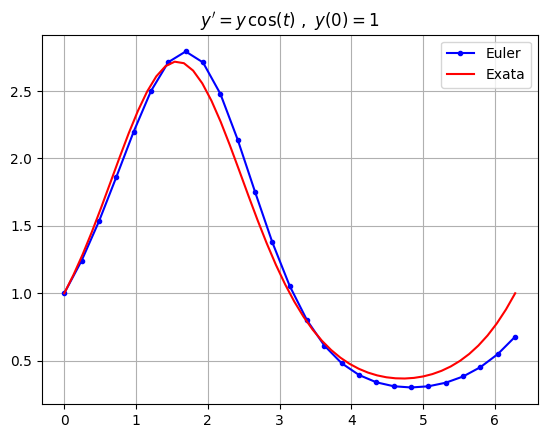

In [3]:
f = lambda t,y: y*np.cos(t)
y0 = 1; t0 = 0; tf = 2*np.pi;
h = 0.25; N = int((tf - t0)/h) + 1;
t = np.linspace(t0,tf,N+1)
y = odeEuler(f,t,y0)
plt.plot(t,y,'b.-')
t_exact = np.linspace(t0,tf,50)
y_exact = np.exp(np.sin(t_exact))
plt.plot(t_exact,y_exact,'r')
plt.grid(True), plt.title("$y' = y \, \cos(t) \ , \ y(0)=1$")
plt.legend(["Euler","Exata"])
plt.show()

## Método de Heun

O método de Euler usa o polinômio de Taylor de grau 1 (ou seja, a reta tangente) para aproximar $y(t)$. O [método de Heun](https://en.wikipedia.org/wiki/Heun%27s_method) é construído a partir do polinômio de Taylor de grau 2:

$$
y(t + h) \approx y(t) + y'(t)h + \frac{y''(t)}{2}h^2
$$

Queremos usar apenas $y' = f(t,y)$ em nossa aproximação, portanto, introduzimos a fórmula de diferença progressiva para aproximar $y''$ em termos de $y'$:

$$
y''(t) \approx \frac{y'(t + h) - y'(t)}{h}
$$

Juntamos isso para aproximar $y(t + h)$:

$$
y(t+h) \approx y(t) + \frac{y'(t + h) + y'(t)}{2}h
$$

Usamos o método de Euler $y(t+h) \approx y(t) + y'(t)h$ para aproximar:

$$
y'(t+h) = f(t+h,y(t+h)) \approx f(t+h,y(t)+y'(t)h)
$$

O método de Heun é dado pela fórmula recursiva de 2 estágios:

\begin{align}
h &= t_{n+1} - t_n \\\
k_1 &= f(t_n,y_n) \\\
k_2 &= f(t_n + h,y_n + k_1 h) \\\
y_{n+1} &= y_n + \left( \frac{k_1 + k_2}{2} \right)h
\end{align}

Escreva uma função chamada `odeHeun` que receba os parâmetros de entrada `f`, `t` e `y0`, onde:

* `f` é uma função que representa o lado direito da equação $y' = f(t,y)$
* `t` é um array NumPy 1D
* `y0` é um valor inicial $y(t_0)=y_0$ onde $t_0$ é o valor `t[0]`

A função `odeHeun` retorna um array NumPy 1D de valores de $y$ que aproximam a solução $y(t)$ usando o método de Heun.

In [4]:
def odeHeun(f,t,y0):
    y = np.zeros(len(t))
    y[0] = y0
    for n in range(0,len(t)-1):
        h = t[n+1] - t[n]
        k1 = f(t[n],y[n])
        k2 = f(t[n+1],y[n] + k1*h)
        y[n+1] = y[n] + (k1 + k2)/2*h
    return y

Vamos novamente considerar a equação

$$
y' = y \cos(t) \ , \ \ y(0)=1
$$

e a solução exata

$$
y(t) = e^{\sin(t)}
$$

Plote a aproximação usando tanto o método de Euler quanto o método de Heun com um passo de tamanho $h=0.25$ e plote a solução exata no intervalo $0 \leq t \leq 2 \pi$.

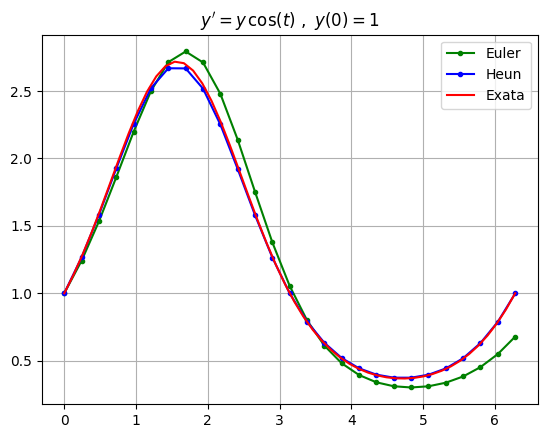

In [5]:
f = lambda t,y: y*np.cos(t)
y0 = 1; t0 = 0; tf = 2*np.pi;
h = 0.25; N = int((tf - t0)/h) + 1;
t = np.linspace(t0,tf,N+1)
y_euler = odeEuler(f,t,y0); plt.plot(t,y_euler,'g.-');
y_heun = odeHeun(f,t,y0); plt.plot(t,y_heun,'b.-');
t_exact = np.linspace(t0,tf,50)
y_exact = np.exp(np.sin(t_exact))
plt.plot(t_exact,y_exact,'r')
plt.grid(True), plt.title("$y' = y \, \cos(t) \ , \ y(0)=1$")
plt.legend(["Euler","Heun","Exata"])
plt.show()

O método de Heun calcula uma aproximação melhor em comparação com o método de Euler, como esperado.

## Análise de Erro

### Ordem de Precisão

Seja $y_1$ a aproximação de $y(t_1)$ por um passo de algum método numérico usando um passo de tamanho $h = t_1 - t_0$. O **erro de truncamento (local)** (para a equação diferencial e método dados) é

$$
E(h) = | y(t_1) - y_1 |
$$

A palavra *local* significa que estamos olhando para apenas um passo do método e a palavra *truncamento* tem a ver com o truncamento da série de Taylor.

A maioria dos métodos numéricos é baseada em séries de Taylor, portanto, o erro pode ser expresso em termos do teorema de Taylor. Por exemplo, considere a série de Taylor até a ordem $p$ avaliada em $t_1 = t_0 + h$:

$$
y(t_1) = y(t_0) + y'(t_0)h + \cdots + \frac{y^{(p)}(t_0)}{p!} h^p + \frac{y^{(p+1)}(c)}{(p+1)!} h^{p+1}
$$

para algum $c \in [t_0,t_1]$. Se um método numérico calcula $y(t_1)$ usando o polinômio de Taylor de grau $p$, então o erro de truncamento local é

$$
E(h) = | y(t_1) - y_1 | = \frac{| y^{(p+1)}(c) |}{(p+1)!} h^{p+1}
$$

Portanto, podemos dizer grosseiramente que um método numérico é de ordem $p$ se o erro de truncamento local se parece com $Ch^{p+1}$ para alguma constante $C$.

Mais precisamente, um método numérico é de **ordem** $p$ se o erro de truncamento local satisfaz

$$
E(h) \leq C h^{p+1}
$$

para *qualquer* equação $y' = f(t,y)$, $y(t_0)=y_0$. A constante $C$ depende de $f$. Note que a ordem é um inteiro positivo.

Geralmente é bastante difícil determinar a ordem de um método numérico dada a fórmula. Em vez disso, podemos determinar a ordem experimentalmente. A ideia é que o erro de truncamento local deve satisfazer

$$
E(h) \approx C h^{p+1}
$$

quando aplicado à maioria das equações diferenciais. Portanto, podemos observar a inclinação no gráfico log-log:

$$
\log(E(h)) \approx (p+1) \log(h) + \log(C)
$$

O procedimento para determinar experimentalmente a ordem $p$ de um método numérico é:

1. Aplique o método numérico à equação $y' = y,y(0)=1$ para diferentes tamanhos de passo $h_1$ e $h_2$.
2. Calcule os erros de truncamento locais $E(h_1)$ e $E(h_2)$ usando a solução exata $y(t)=e^t$.
3. Calcule a inclinação do gráfico log-log:

$$
p+1 \approx \frac{\log(E(h_2)) - \log(E(h_1))}{\log(h_2) - \log(h_1)}
$$

### Exemplos

#### O Método de Euler é de Ordem 1

O método de Euler é construído usando o polinômio de Taylor de grau 1. O teorema de Taylor diz

$$
y(t_1) = y(t_0) + y'(t_0)(t_1 - t_0) + \frac{y''(c)}{2}(t_1 - t_0)^2
$$

para algum $c \in [t_0,t_1]$. Portanto, se $|y''(t)|\leq K_2$ para todo $t \in [t_0,t_1]$, então

$$
E(h) = \left| \frac{y''(c)}{2}(t_1 - t_0)^2 \right| \leq \frac{K_2 h^2}{2}
$$

Portanto, o método de Euler é de ordem 1. Vamos verificar a ordem do método de Euler experimentalmente, plotando o erro de truncamento local para o método de Euler aplicado a $y'=y$, $y(0)=1$.

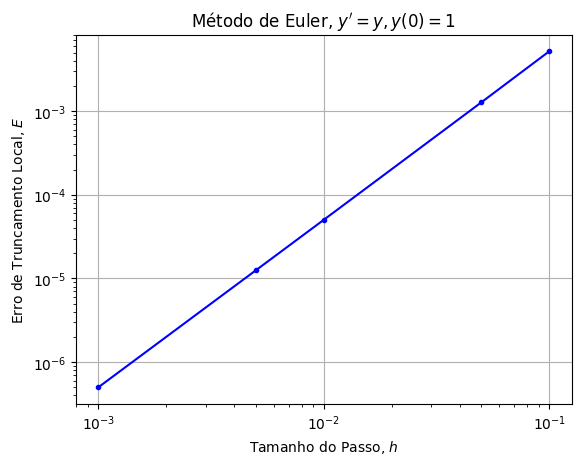

A ordem do método é 1.008325982940494


In [6]:
f = lambda t,y: y
y0 = 1;
h = [0.1,0.05,0.01,0.005,0.001]
E = np.zeros(len(h))
for n in range(0,len(h)):
    y = odeEuler(f,[0,h[n]],y0)
    y1 = y[1]
    y1_exact = np.exp(h[n])
    E[n] = np.abs(y1_exact - y1)

plt.loglog(h,E,'b.-'), plt.grid(True)
plt.title("Método de Euler, $y'=y,y(0)=1$")
plt.xlabel("Tamanho do Passo, $h$"), plt.ylabel("Erro de Truncamento Local, $E$")
plt.show()

p = (np.log(E[2])-np.log(E[1]))/(np.log(h[2])-np.log(h[1])) - 1

print("A ordem do método é",p)

O gráfico log-log tem inclinação 2, como esperado da fórmula de erro, e verificamos que o método de Euler é de ordem 1.

#### O Método de Heun é de Ordem 2

O método de Heun é construído usando o polinômio de Taylor de grau 2, portanto, esperamos que o método seja de ordem 2. Vamos verificar a ordem do método de Heun experimentalmente, plotando o erro de truncamento local para o método de Heun aplicado a $y'=y$, $y(0)=1$.

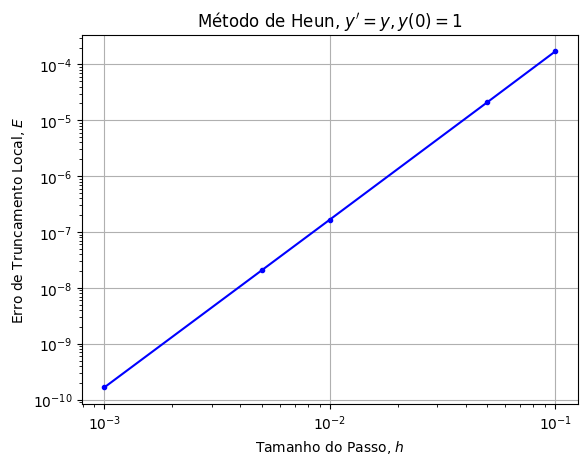

A ordem do método é 2.006241389698562


In [7]:
f = lambda t,y: y
y0 = 1;
h = [0.1,0.05,0.01,0.005,0.001]
E = np.zeros(len(h))
for n in range(0,len(h)):
    y = odeHeun(f,[0,h[n]],y0)
    y1 = y[1]
    y1_exact = np.exp(h[n])
    E[n] = np.abs(y1_exact - y1)

plt.loglog(h,E,'b.-'), plt.grid(True)
plt.title("Método de Heun, $y'=y,y(0)=1$")
plt.xlabel("Tamanho do Passo, $h$"), plt.ylabel("Erro de Truncamento Local, $E$")
plt.show()

p = (np.log(E[2])-np.log(E[1]))/(np.log(h[2])-np.log(h[1])) - 1

print("A ordem do método é",p)

O gráfico log-log tem inclinação 3, portanto, o método de Heun é de ordem 2, como esperado, já que o método de Heun é construído a partir da aproximação de Taylor de grau 2.

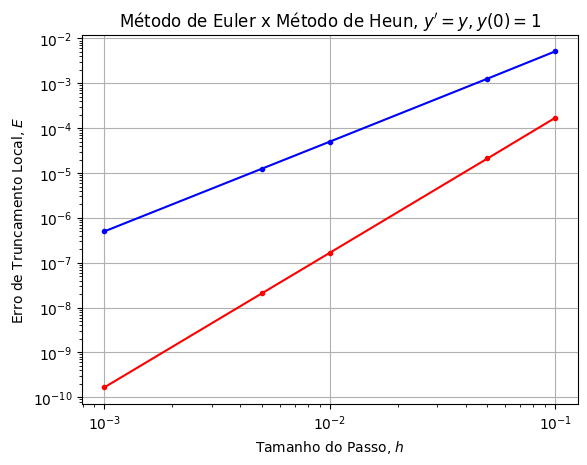

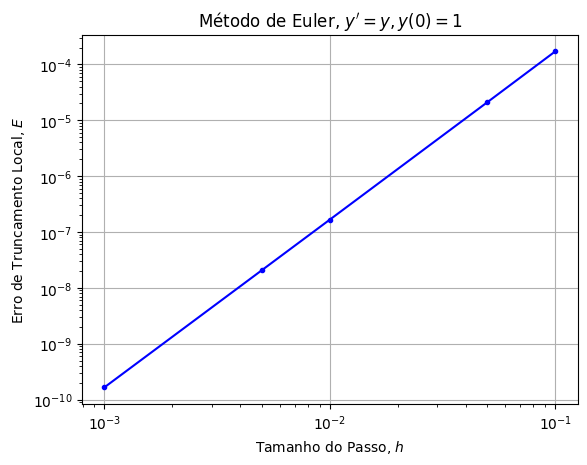

In [8]:
f = lambda t,y: y
y0 = 1;
h = [0.1,0.05,0.01,0.005,0.001]
E1 = np.zeros(len(h))
E2 = np.zeros(len(h))
for n in range(0,len(h)):
    y = odeEuler(f,[0,h[n]],y0)
    y1 = y[1]
    y1_exact = np.exp(h[n])
    E1[n] = np.abs(y1_exact - y1)
    y = odeHeun(f,[0,h[n]],y0)
    y1 = y[1]
    y1_exact = np.exp(h[n])
    E2[n] = np.abs(y1_exact - y1)

plt.loglog(h,E1,'b.-'), plt.loglog(h,E2,'r.-'),plt.grid(True)
plt.title("Método de Euler x Método de Heun, $y'=y,y(0)=1$")
plt.xlabel("Tamanho do Passo, $h$"), plt.ylabel("Erro de Truncamento Local, $E$")
plt.show()

plt.loglog(h,E,'b.-'), plt.grid(True)
plt.title("Método de Euler, $y'=y,y(0)=1$")
plt.xlabel("Tamanho do Passo, $h$"), plt.ylabel("Erro de Truncamento Local, $E$")
plt.show()

## scipy.integrate.odeint

O principal pacote para resolver EDOs numericamente no SciPy é `scipy.integrate.odeint`. Assim como nossas funções `odeEuler` e outras definidas acima, a função `odeint` recebe os parâmetros de entrada `f`, `y0` e `t`, onde:

* `f` é uma função que representa o lado direito da equação $y' = f(y,t)$ (note a ordem, $y$ e depois $t$)
* `y0` é um valor inicial $y(t_0)=y_0$ onde $t_0$ é o valor `t[0]`
* `t` é um array NumPy 1D

A função `odeint` retorna um array NumPy 1D de valores de $y$ que aproximam a solução $y(t)$. Note que nossa notação para equações de primeira ordem (e a notação usada pela maioria dos matemáticos) é $y'=f(t,y)$, com $t$ aparecendo primeiro e depois $y$. A função `odeint` **espera uma ordem diferente de variáveis**, com $y$ aparecendo primeiro e depois $t$ na equação $y' = f(y,t)$.

Por exemplo, use `odeint` para aproximar a solução de $y' = \sin(y^2) + \cos(t)$ para vários valores iniciais.

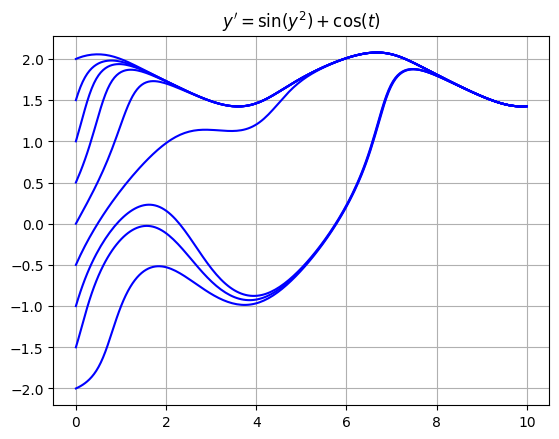

In [10]:
import scipy.integrate as spi

f = lambda y,t: np.sin(y**2) + np.cos(t)
t = np.linspace(0,10,200)
for y0 in np.linspace(-2,2,9):
    y = spi.odeint(f,y0,t)
    plt.plot(t,y,'b')

plt.grid(True), plt.title("$y' = \sin(y^2) + \cos(t)$")
plt.show()

# Exercícios

**Exercício 1.** Plote o campo de inclinação de $y' = \sin(t) + \cos(y)$ no intervalo $0 \leq t \leq 2\pi$, $-2 \leq y \leq 2$ com um passo de grade $h = 0.2$. Se $y(t)$ é a solução com valor inicial $y(0) = 0.5$, estime o valor $y(2\pi)$.

**Exercício 2.** Escreva uma função chamada `odeMidpoint` que implemente o método do ponto médio:

\begin{align}
k_1 &= f(t_n,y_n) \\\
k_2 &= f(t_n + h/2, y_n + k_1 h/2) \\\
y_{n+1} &= y_n + k_2 h
\end{align}

Determine a ordem do método do ponto médio.

**Exercício 3.** Use `scipy.integrate.odeint` para aproximar $y(1)$ onde $y(t)$ é a solução das equações

$$
y' = t - y^3 \ , \ \ y(0)=1
$$